# Seismic inversion for oil exploration

Finding oil is an inverse problem dressed in geology. A reservoir is a body of porous rock, buried a
kilometre or two down, whose pore space holds hydrocarbons instead of water. We cannot see it; we can only
bounce sound off the earth and record the echoes at the surface and in a few boreholes. From those echoes we
must reconstruct the subsurface, decide whether a trap holds oil, estimate how much, and quantify how sure
we are -- because the next step is a well that costs tens of millions of dollars.

This notebook is a complete, self-contained tutorial in that chain. It proceeds:

1. The petroleum system -- what makes a prospect, and why seismic can see it.
2. Rock physics -- how porosity and pore fluid set seismic velocity (Gassmann fluid substitution); why oil and gas show up.
3. The seismic experiment -- waves, impedance, reflection, the wavelet, and the convolutional model; a synthetic well tie.
4. Building an earth model -- a fine, realistic 3D velocity model with layers, an unconformity, a fault, an anticlinal trap, and a fluid-filled reservoir.
5. Acquisition -- sources and receivers at the surface and in boreholes; illumination and fold.
6. Forward modelling -- the acoustic wave equation in the frequency domain (Helmholtz), solved per source and frequency.
7. Conventional imaging -- migration as the adjoint, and why it is not the whole story.
8. The full-waveform inversion objective -- misfit, the adjoint-state gradient, cycle skipping, and multiscale frequency continuation.
9. Bayesian FWI on mixle -- a GP velocity field, a Helmholtz forward, and a posterior with uncertainty.
10. The recovered reservoir and its uncertainty -- driven by the survey's illumination.
11. Quantitative interpretation -- turning recovered velocity into porosity, fluid, net pay, and oil-in-place volumes, with error bars.
12. Time-lapse (4D) monitoring -- imaging production by inverting the change between two surveys.
13. The drilling decision -- a probability-of-pay map and the value of the inversion.

The forward physics is the acoustic wave equation; the inversions are posed as Bayesian problems on
mixle's PDE-inverse stack, so each reconstruction carries a calibrated uncertainty. The earth model is
synthetic but built to be realistic -- the velocities come from a standard rock-physics model, the structure
from ordinary geology. It is illustrative, not a specific field; the frequencies and dimensions are chosen
to keep the 3D wave solves fast enough to run in a notebook.

## 1. The petroleum system

Oil and gas are generated when organic-rich source rock is buried deep enough to cook (the oil window, very
roughly 2-4 km and 60-120 C). Being lighter than the pore water, the hydrocarbons migrate upward and
sideways through permeable rock until something stops them. A commercial accumulation needs four things to
coincide in space and time:

- a reservoir: porous, permeable rock (typically sandstone or carbonate) with room to hold fluid in its pores;
- a trap: a geometry that halts upward migration -- an anticline (a domed fold, our case), a fault seal, or a stratigraphic pinch-out;
- a seal: an impermeable cap (usually shale or salt) over the trap;
- a charge: a mature source rock connected to the trap by a migration path.

When all four line up, hydrocarbons collect in the crest of the trap, lightest on top: a gas cap, then an oil
column, resting on the original formation water. The boundaries between them -- the gas-oil contact (GOC) and
oil-water contact (OWC) -- are essentially flat, set by gravity, and they cut across the dipping reservoir
rock. That flatness is a giveaway on seismic.

Why seismic works at all: the pore fluid changes the rock's seismic velocity and density. Replacing brine
with oil, and especially with gas, lowers both. A gas-filled sand can be markedly slower and lighter than
the same sand full of water, producing a strong reflection -- a bright spot -- and sometimes a visible flat
reflection at the fluid contact. Seismic does not see oil directly; it sees the velocity and density
contrasts that oil creates. Quantifying those contrasts is what the rest of this notebook is about.

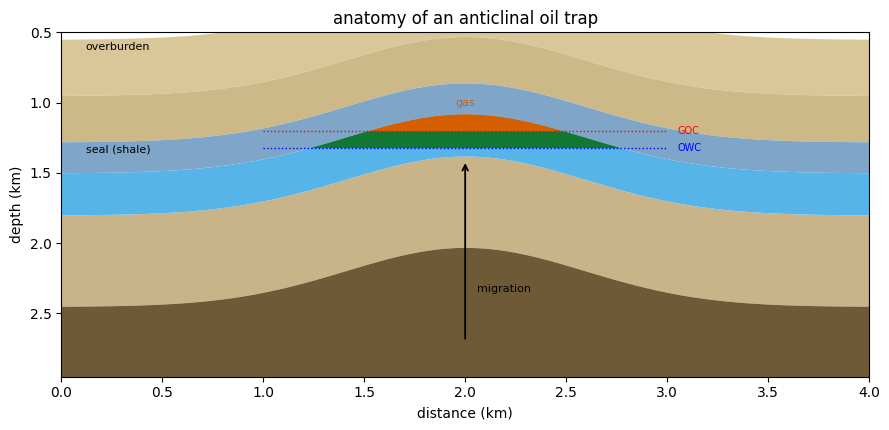

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# a schematic of the petroleum system: anticlinal trap, reservoir, seal, contacts, migration
fig, ax = plt.subplots(figsize=(9, 4.4))
xx = np.linspace(0, 4, 400)
def fold(base, amp=0.42):
    return base - amp * np.exp(-((xx - 2.0) ** 2) / 0.7)
# bands from shallow (top) to deep (bottom): tops given, each band reaches the next top
tops = [(0.55, '#d9c79a', 'overburden'), (0.95, '#cdb988', ''), (1.28, '#7fa6c9', 'seal (shale)'),
        (1.50, None, 'reservoir'), (1.80, '#c9b48a', ''), (2.45, '#9a8050', 'source rock')]
for k in range(len(tops) - 1):
    base, col, lab = tops[k]; nxt = tops[k + 1][0]
    if col is None: continue
    ax.fill_between(xx, fold(base), fold(nxt), color=col, lw=0)
    if lab: ax.text(0.12, fold(base).max() + 0.02, lab, fontsize=8, va='top')
ax.fill_between(xx, fold(2.45), 2.95, color='#6e5a36', lw=0)
# reservoir sand with gas / oil / brine by depth inside the crest
rtop, rbot = fold(1.50), fold(1.80)
goc, owc = rtop.min() + 0.12, rtop.min() + 0.24
ax.fill_between(xx, rtop, rbot, color='#56B4E9', lw=0)                                   # brine (default)
ax.fill_between(xx, np.maximum(rtop, goc), np.minimum(rbot, owc), where=rtop < owc, color='#117733', lw=0)  # oil
ax.fill_between(xx, rtop, np.minimum(rbot, goc), where=rtop < goc, color='#D55E00', lw=0)                    # gas cap
for y, lab, c in [(goc, 'GOC', 'r'), (owc, 'OWC', 'b')]:
    ax.plot([1.0, 3.0], [y, y], c + ':', lw=1.0); ax.text(3.05, y, lab, fontsize=7, color=c, va='center')
ax.annotate('', xy=(2.0, rbot.min() + 0.03), xytext=(2.0, 2.7), arrowprops=dict(arrowstyle='->', color='k', lw=1.3))
ax.text(2.06, 2.35, 'migration', fontsize=8)
ax.text(2.0, rtop.min() - 0.04, 'gas', fontsize=8, color='#D55E00', ha='center', va='bottom')
ax.set_ylim(2.95, 0.5); ax.set_xlim(0, 4); ax.set_xlabel('distance (km)'); ax.set_ylabel('depth (km)')
ax.set_title('anatomy of an anticlinal oil trap'); plt.tight_layout(); plt.show()

## 2. Rock physics: from rock and fluid to seismic velocity

To predict (and later invert) what seismic sees, we need the link from rock and fluid to velocity. For a
fluid-saturated porous rock the compressional velocity is
$$ V_p = \sqrt{\frac{K_{\mathrm{sat}} + \tfrac{4}{3}\mu}{\rho}}, $$
with bulk modulus $K_{\mathrm{sat}}$, shear modulus $\mu$, and density $\rho$. The pore fluid enters through
$K_{\mathrm{sat}}$ and $\rho$ only; the shear modulus $\mu$ is unaffected by the fluid (a fluid has no shear
strength). Gassmann's equation gives the saturated bulk modulus from the dry-rock frame $K_{\mathrm{dry}}$,
the mineral modulus $K_0$, the porosity $\phi$, and the fluid modulus $K_{\mathrm{fl}}$:
$$ K_{\mathrm{sat}} = K_{\mathrm{dry}} + \frac{\left(1 - K_{\mathrm{dry}}/K_0\right)^2}
{\phi/K_{\mathrm{fl}} + (1-\phi)/K_0 - K_{\mathrm{dry}}/K_0^2}, \qquad
\rho = (1-\phi)\rho_0 + \phi\,\rho_{\mathrm{fl}}. $$
Gas has a tiny bulk modulus (it is compressible) and low density, so a gas-filled rock has both a lower
$K_{\mathrm{sat}}$ and a lower $\rho$ -- a large velocity and impedance drop. Oil is intermediate; brine is
stiffest and densest. Below we substitute the three fluids into one reservoir sand and trace the effect on
velocity, density, and acoustic impedance $\mathrm{AI} = \rho V_p$, and we sweep porosity to show the
broader trend.

brine   Vp = 2.661 km/s   rho = 2.12 g/cc   AI = 5.63
oil     Vp = 2.344 km/s   rho = 2.04 g/cc   AI = 4.78
gas     Vp = 2.211 km/s   rho = 1.85 g/cc   AI = 4.09
seal shale  Vp = 3.05   rho = 2.45   AI = 7.47


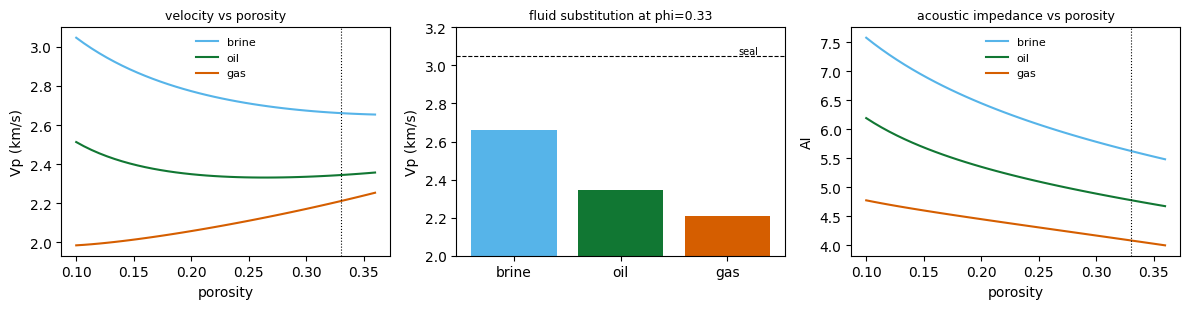

In [2]:
Kmin, Gmin, rhomin = 37.0, 44.0, 2.65          # quartz: bulk, shear (GPa), density (g/cc)
def gassmann(phi, Kdry, Gdry, Kfl, rhofl):
    Ksat = Kdry + (1 - Kdry / Kmin) ** 2 / (phi / Kfl + (1 - phi) / Kmin - Kdry / Kmin ** 2)
    rho = (1 - phi) * rhomin + phi * rhofl
    Vp = np.sqrt((Ksat + 4 / 3 * Gdry) * 1e9 / (rho * 1000)) / 1000
    return Vp, rho
PHI, KDRY, GDRY = 0.33, 3.5, 4.0               # reservoir sand: porosity, dry-frame moduli (GPa)
FLUIDS = {'brine': (2.8, 1.03), 'oil': (1.0, 0.80), 'gas': (0.08, 0.22)}   # (K_fl GPa, rho g/cc)
COLF = {'brine': '#56B4E9', 'oil': '#117733', 'gas': '#D55E00'}
rockphys = {}
for f, (Kfl, rhofl) in FLUIDS.items():
    Vp, rho = gassmann(PHI, KDRY, GDRY, Kfl, rhofl); rockphys[f] = (Vp, rho, rho * Vp)
    print('%-6s  Vp = %.3f km/s   rho = %.2f g/cc   AI = %.2f' % (f, Vp, rho, rho * Vp))
shale = (3.05, 2.45); print('seal shale  Vp = %.2f   rho = %.2f   AI = %.2f' % (shale[0], shale[1], shale[0] * shale[1]))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
phis = np.linspace(0.10, 0.36, 40)
for f, (Kfl, rhofl) in FLUIDS.items():
    Vp = np.array([gassmann(p, KDRY, GDRY, Kfl, rhofl)[0] for p in phis])
    AI = np.array([np.prod(gassmann(p, KDRY, GDRY, Kfl, rhofl)) for p in phis])
    ax[0].plot(phis, Vp, color=COLF[f], label=f)
    ax[2].plot(phis, AI, color=COLF[f], label=f)
ax[0].axvline(PHI, color='k', ls=':', lw=0.8); ax[0].set_xlabel('porosity'); ax[0].set_ylabel('Vp (km/s)'); ax[0].set_title('velocity vs porosity', fontsize=9); ax[0].legend(fontsize=8, frameon=False)
bars = [rockphys[f][0] for f in FLUIDS]
ax[1].bar(range(3), bars, color=[COLF[f] for f in FLUIDS]); ax[1].set_xticks(range(3)); ax[1].set_xticklabels(FLUIDS.keys())
ax[1].axhline(shale[0], color='k', ls='--', lw=0.8); ax[1].text(2.1, shale[0] + 0.01, 'seal', fontsize=7)
ax[1].set_ylabel('Vp (km/s)'); ax[1].set_title('fluid substitution at phi=0.33', fontsize=9); ax[1].set_ylim(2.0, 3.2)
ax[2].axvline(PHI, color='k', ls=':', lw=0.8); ax[2].set_xlabel('porosity'); ax[2].set_ylabel('AI'); ax[2].set_title('acoustic impedance vs porosity', fontsize=9); ax[2].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 3. The seismic experiment: impedance, reflection, and the wavelet

A seismic wave reflects wherever acoustic impedance changes. At a flat interface between layers of impedance
$\mathrm{AI}_1$ above and $\mathrm{AI}_2$ below, the normal-incidence reflection coefficient is
$$ R = \frac{\mathrm{AI}_2 - \mathrm{AI}_1}{\mathrm{AI}_2 + \mathrm{AI}_1}. $$
A reflectivity series $r(t)$ is the set of these coefficients placed at the two-way travel times of the
interfaces. The source emits not a spike but a band-limited wavelet $w(t)$ (here a Ricker), and to a good
first approximation the recorded trace is their convolution,
$$ s(t) = (w * r)(t). $$
This convolutional model is the workhorse of seismic interpretation. Below we build a 1-D well log through
the crest of our prospect -- velocity and density versus depth, with the reservoir sand full of gas -- form
its impedance and reflectivity, convert to two-way time, and convolve with a wavelet to make the synthetic
trace. The result shows the textbook signature of a gas reservoir: a strong trough (a negative reflection)
at the top of the gas sand -- the bright spot -- and a flat reflection at the fluid contact.

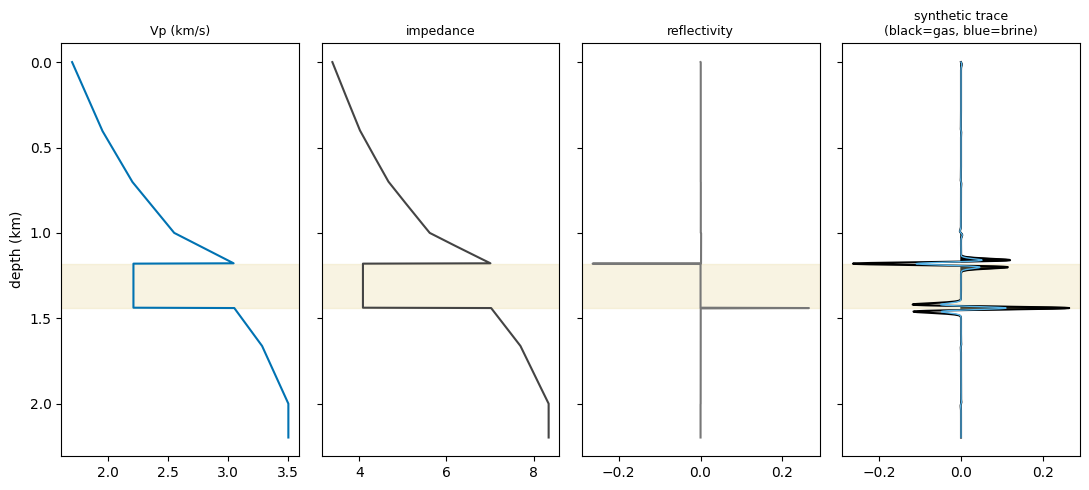

top-gas reflection coefficient = -0.264 (a strong trough: the bright spot)


In [3]:
# 1-D log through the crest: depth, Vp, density -> impedance -> reflectivity -> synthetic trace
dz = 0.002; depth = np.arange(0.0, 2.2, dz)
def crest_log(fluid='gas'):
    Vp = np.interp(depth, [0, 0.4, 0.7, 1.0, 1.18, 1.44, 1.66, 2.0],
                          [1.7, 1.95, 2.2, 2.55, 3.05, 3.05, 3.28, 3.5])         # background + seal
    rho = 0.31 * (Vp * 1000) ** 0.25                                            # Gardner's relation (g/cc)
    res = (depth >= 1.18) & (depth < 1.44)                                       # reservoir interval at the crest
    Vp[res], rho[res] = rockphys[fluid][0], rockphys[fluid][1]
    return Vp, rho
def reflectivity(Vp, rho):
    AI = rho * Vp; r = np.zeros_like(AI); r[1:] = (AI[1:] - AI[:-1]) / (AI[1:] + AI[:-1]); return AI, r
Vp, rho = crest_log('gas'); AI, r = reflectivity(Vp, rho)
_, r_brine = reflectivity(*crest_log('brine'))
fc = 30.0; tw = np.linspace(-0.05, 0.05, 81)
wav = (1 - 2 * (np.pi * fc * tw) ** 2) * np.exp(-(np.pi * fc * tw) ** 2)         # Ricker wavelet
synth = np.convolve(r, wav, mode='same'); synth_brine = np.convolve(r_brine, wav, mode='same')

fig, ax = plt.subplots(1, 4, figsize=(11, 5), sharey=True)
ax[0].plot(Vp, depth, color='#0072B2'); ax[0].set_title('Vp (km/s)', fontsize=9); ax[0].set_ylabel('depth (km)'); ax[0].invert_yaxis()
ax[1].plot(AI, depth, color='#444'); ax[1].set_title('impedance', fontsize=9)
ax[2].plot(r, depth, color='#777'); ax[2].set_title('reflectivity', fontsize=9)
ax[3].plot(synth, depth, color='k'); ax[3].fill_betweenx(depth, 0, synth, where=synth > 0, color='k')
ax[3].plot(synth_brine, depth, color='#56B4E9', lw=1.0)
ax[3].set_title('synthetic trace\n(black=gas, blue=brine)', fontsize=9)
for a in ax:
    a.axhspan(1.18, 1.44, color='#e8d9a0', alpha=0.3)
plt.tight_layout(); plt.show()
print('top-gas reflection coefficient = %.3f (a strong trough: the bright spot)' % r[np.argmin(np.abs(depth - 1.18))])

## 4. Building the earth model

We now assemble a 3D velocity model that a geologist would recognise. The domain is 4 km x 4 km across and
2.5 km deep. From the top: a compacting overburden of sediments (velocity rising with depth) cut by a normal
fault; an angular unconformity beneath which older beds are tilted and truncated; a sealing shale; the
reservoir sand, folded into a gentle anticline that closes in four directions (the trap); and a fast basement
below. The reservoir is filled with brine everywhere except inside the structural closure, where -- using the
Gassmann velocities computed in Part 2 -- a gas cap sits above an oil rim above the original water, with flat
gas-oil and oil-water contacts. We render it on a fine grid so the structure is crisp; the inversion later
runs on a coarser grid, as in practice.

The same builder produces two models we will need: the in-situ model (with hydrocarbons), which generates the
observed data, and a baseline model (the reservoir full of brine, i.e. no hydrocarbons), which is the regional
expectation from well logs and is used as the starting model. The difference between them is the fluid anomaly
the inversion is after.

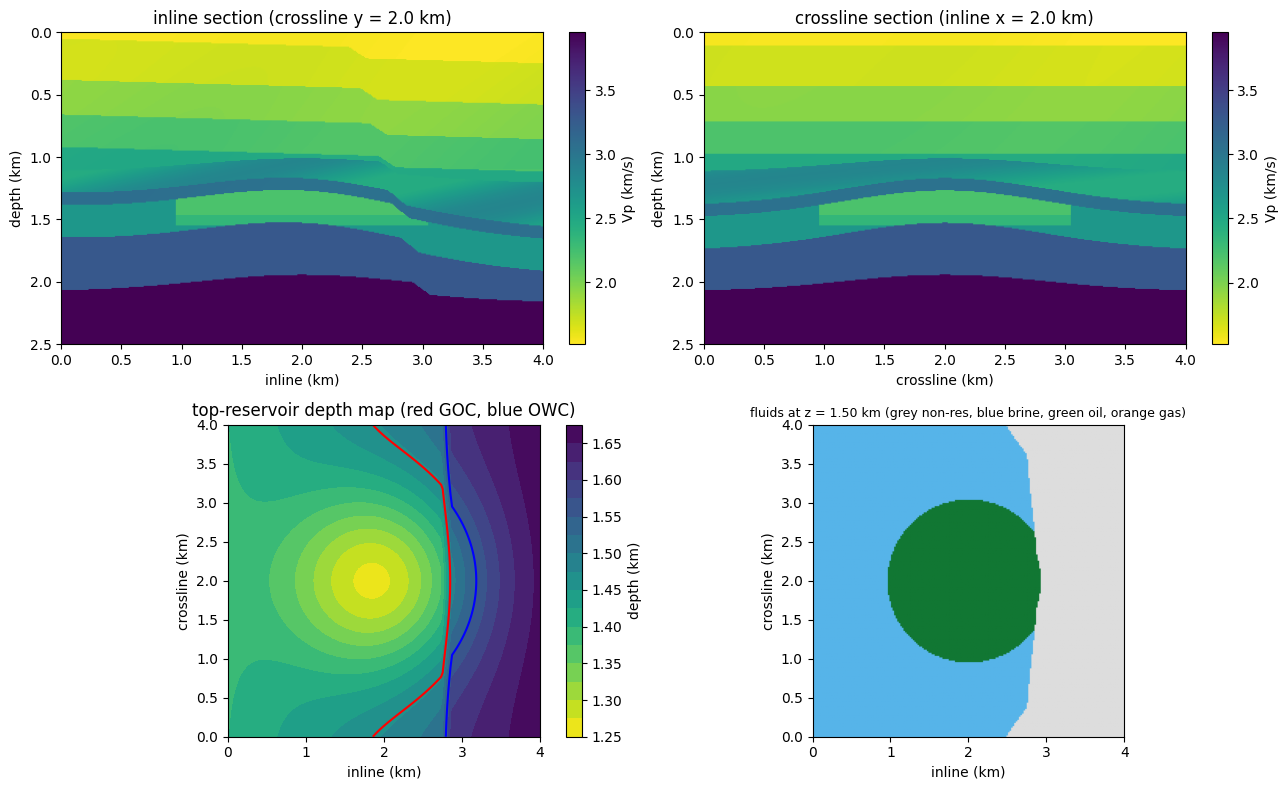

In [4]:
Lx, Ly, Lz = 4.0, 4.0, 2.5
XC, YC = 2.0, 2.0
GOC, OWC, R_CLOS = 1.47, 1.55, 1.05
_rng = np.random.RandomState(7); _kx = _rng.randn(6, 6, 6); _ph = _rng.rand(6, 6, 6) * 6.28
def _hetero(X, Y, Z, amp):
    f = np.zeros_like(X * 1.0)
    for a in range(3):
        for b in range(3):
            for cc in range(2):
                f += _kx[a, b, cc] * np.sin((a + 1) * np.pi * X / Lx + (b + 1) * np.pi * Y / Ly + (cc + 1) * np.pi * Z / Lz + _ph[a, b, cc])
    return amp * f / 6.0
def _dome(X, Y, A=0.22, s=0.85):
    return -A * np.exp(-(((X - XC) ** 2 + (Y - YC) ** 2) / (2 * s ** 2)))
def _throw(X, Y, Z, xf0=2.75, dip=0.28, throw=0.09):
    xf = xf0 + dip * (Z - 1.4); return throw * np.clip((X - xf) / 0.12, 0, 1)
def build_earth(X, Y, Z, fluid='insitu'):
    X, Y, Z = X * 1.0, Y * 1.0, Z * 1.0
    fz = _throw(X, Y, Z); d = _dome(X, Y); dip = 0.045 * X
    V = np.full(X.shape, 1.55)
    for base, vel in [(0.05, 1.70), (0.38, 1.95), (0.66, 2.20), (0.92, 2.48)]:
        V[Z > base + dip * 0.6 + fz] = vel
    V = V + _hetero(X, Y, Z, 0.04) * (Z < 1.1)
    U = 1.12 + 0.5 * d + fz; older = Z > U
    Vold = np.clip(2.62 + 0.22 * np.sin((Z + 0.22 * X + 0.10 * Y) * 8.5), 2.45, 3.0)
    V[older] = Vold[older]
    top_seal = 1.30 + dip + d + fz; top_res = 1.40 + dip + d + fz
    base_res = 1.66 + dip + d + fz; basement = 2.08 + 0.6 * d + fz
    seal = Z > top_seal; V[seal] = 3.05 + _hetero(X, Y, Z, 0.03)[seal]
    inres = (Z > top_res) & (Z <= base_res); V[inres] = rockphys['brine'][0]
    V[Z > base_res] = 3.28; V[Z > basement] = 3.95
    if fluid != 'brine':
        r = np.sqrt((X - XC) ** 2 + (Y - YC) ** 2); closed = inres & (r < R_CLOS)
        if fluid == 'insitu':
            V[closed & (Z < GOC)] = rockphys['gas'][0]
            V[closed & (Z >= GOC) & (Z < OWC)] = rockphys['oil'][0]
        elif fluid == 'depleted':                                   # 4D: water has swept the oil leg; the gas cap remains
            V[closed & (Z < GOC)] = rockphys['gas'][0]              # gas cap unchanged; the oil ring reverts to brine
    return V, dict(top_res=top_res, base_res=base_res, inres=inres)

# fine sections + structure map
nxf, nzf = 420, 300; nyf = 360
xs = np.linspace(0, Lx, nxf); zs = np.linspace(0, Lz, nzf); ysf = np.linspace(0, Ly, nyf)
Xi, Zi = np.meshgrid(xs, zs, indexing='ij'); Vi, _ = build_earth(Xi, np.full_like(Xi, YC), Zi)
Yx, Zx = np.meshgrid(ysf, zs, indexing='ij'); Vx, _ = build_earth(np.full_like(Yx, XC), Yx, Zx)
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
im = ax[0, 0].imshow(Vi.T, origin='upper', extent=[0, Lx, Lz, 0], cmap='viridis_r', aspect='auto')
ax[0, 0].set_title('inline section (crossline y = 2.0 km)'); ax[0, 0].set_xlabel('inline (km)'); ax[0, 0].set_ylabel('depth (km)'); fig.colorbar(im, ax=ax[0, 0], fraction=0.04, label='Vp (km/s)')
im = ax[0, 1].imshow(Vx.T, origin='upper', extent=[0, Ly, Lz, 0], cmap='viridis_r', aspect='auto')
ax[0, 1].set_title('crossline section (inline x = 2.0 km)'); ax[0, 1].set_xlabel('crossline (km)'); ax[0, 1].set_ylabel('depth (km)'); fig.colorbar(im, ax=ax[0, 1], fraction=0.04, label='Vp (km/s)')
nm = 200; xm = np.linspace(0, Lx, nm); ym = np.linspace(0, Ly, nm); Xm, Ym = np.meshgrid(xm, ym, indexing='ij')
fz0 = _throw(Xm, Ym, np.full_like(Xm, 1.4)); topmap = 1.40 + 0.045 * Xm + _dome(Xm, Ym) + fz0
c = ax[1, 0].contourf(Xm, Ym, topmap, levels=18, cmap='viridis_r')
ax[1, 0].contour(Xm, Ym, topmap, levels=[GOC, OWC], colors=['r', 'b'], linewidths=1.5)
ax[1, 0].set_title('top-reservoir depth map (red GOC, blue OWC)'); ax[1, 0].set_xlabel('inline (km)'); ax[1, 0].set_ylabel('crossline (km)'); ax[1, 0].set_aspect('equal'); fig.colorbar(c, ax=ax[1, 0], fraction=0.046, label='depth (km)')
zc = 1.50; base_m = 1.66 + 0.045 * Xm + _dome(Xm, Ym) + fz0; r = np.sqrt((Xm - XC) ** 2 + (Ym - YC) ** 2)
fl = np.zeros(Xm.shape); inr = (zc > topmap) & (zc < base_m); fl[inr] = 1
fl[inr & (r < R_CLOS) & (zc < OWC)] = 2; fl[inr & (r < R_CLOS) & (zc < GOC)] = 3
ax[1, 1].imshow(fl.T, origin='lower', extent=[0, Lx, 0, Ly], cmap=mcolors.ListedColormap(['#dddddd', '#56B4E9', '#117733', '#D55E00']), vmin=0, vmax=3)
ax[1, 1].set_title('fluids at z = 1.50 km (grey non-res, blue brine, green oil, orange gas)', fontsize=9); ax[1, 1].set_xlabel('inline (km)'); ax[1, 1].set_ylabel('crossline (km)'); ax[1, 1].set_aspect('equal')
plt.tight_layout(); plt.show()

## 5. Acquisition geometry

Resolving a reservoir needs energy that passes through it from many directions. We combine three classic
geometries: a surface source-and-receiver spread (the bread and butter of exploration), and two boreholes
flanking the trap with sources and receivers down them. The crosswell paths between the boreholes transmit
energy straight through the reservoir, which is far more sensitive to its interior than surface reflections
alone, and the surface spread ties the result to the regional structure. The inversion runs on a coarser
grid than the earth model above -- about 150 m cells -- which sets the wave solves' size; the velocity model
and acquisition are sampled onto it.

inversion grid 28x28x18 = 14112 cells, 148 m spacing; fluid anomaly in 212 cells
21 sources, 64 receivers


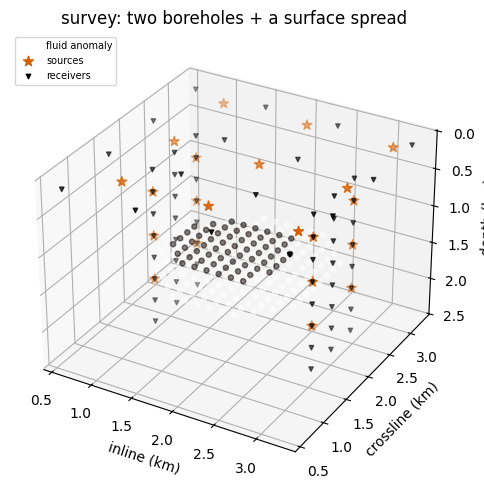

In [5]:
import torch
from mixle.ppl import GP, RBF, joint
from mixle_pde import Differential
from mixle_pde.pde_solve import laplacian
from mixle_pde.ops import make_ops
torch.set_default_dtype(torch.float64); ops = make_ops()

nx, ny, nz = 28, 28, 18; N = nx * ny * nz; h = Lx / (nx - 1)        # ~0.148 km cells (uniform)
gx = np.linspace(0, Lx, nx); gy = np.linspace(0, Ly, ny); gz = np.linspace(0, Lz, nz)
GX, GY, GZ = np.meshgrid(gx, gy, gz, indexing='ij'); vox = np.stack([GX.ravel(), GY.ravel(), GZ.ravel()], 1)
node = lambda ix, iy, iz: ix * ny * nz + iy * nz + iz
V_true, info = build_earth(GX, GY, GZ, 'insitu'); V_base, _ = build_earth(GX, GY, GZ, 'brine')
m_bg = (1.0 / V_base ** 2).ravel()                                  # baseline (no hydrocarbon) = starting model
dm_true = ((1.0 / V_true ** 2) - (1.0 / V_base ** 2)).ravel()       # the fluid anomaly to recover
print('inversion grid %dx%dx%d = %d cells, %.0f m spacing; fluid anomaly in %d cells' % (nx, ny, nz, N, h * 1000, int((np.abs(dm_true) > 1e-4).sum())))

iyc = ny // 2; ixA = int(round(1.0 / h)); ixB = int(round(3.0 / h))
# a dense survey so the imaging is over-determined over the region of interest around the trap
src = ([node(ixA, iy, iz) for iy in (iyc - 3, iyc + 3) for iz in range(4, nz - 3, 4)]   # well A
       + [node(ixB, iy, iz) for iy in (iyc - 3, iyc + 3) for iz in range(4, nz - 3, 4)] # well B
       + [node(ix, iy, 1) for ix in (7, 14, 21) for iy in (7, 14, 21)])                 # surface
rec = np.array([node(ixB, iy, iz) for iy in (iyc - 3, iyc, iyc + 3) for iz in range(2, nz - 1, 2)]   # well B strings
               + [node(ixA, iy, iz) for iy in (iyc - 3, iyc, iyc + 3) for iz in range(2, nz - 1, 2)]  # well A strings
               + [node(ix, iy, 1) for ix in range(4, nx - 3, 6) for iy in range(4, ny - 3, 6)])       # surface spread
rec_t = torch.as_tensor(rec)
print('%d sources, %d receivers' % (len(src), len(rec)))

ax = plt.figure(figsize=(7.5, 5)).add_subplot(111, projection='3d')
rv = np.abs(dm_true) > 1e-4
ax.scatter(vox[rv, 0], vox[rv, 1], vox[rv, 2], c=dm_true[rv], cmap='hot_r', s=14, alpha=0.5, label='fluid anomaly')
sx = vox[src]; rx = vox[rec]
ax.scatter(sx[:, 0], sx[:, 1], sx[:, 2], c='#D55E00', marker='*', s=55, label='sources')
ax.scatter(rx[:, 0], rx[:, 1], rx[:, 2], c='k', marker='v', s=10, label='receivers')
ax.set_xlabel('inline (km)'); ax.set_ylabel('crossline (km)'); ax.set_zlabel('depth (km)'); ax.invert_zaxis()
ax.legend(fontsize=7, loc='upper left'); ax.set_title('survey: two boreholes + a surface spread'); plt.tight_layout(); plt.show()

## 6. Forward modelling: the wave equation in the frequency domain

In the frequency domain the acoustic wave equation becomes the Helmholtz equation. For a point source at node
$s$ and angular frequency $\omega = 2\pi f$, the complex wavefield $u$ solves
$$ \nabla^2 u + \omega^2\, m(\mathbf{x})\, u = -\,\delta_s, \qquad m = 1/V_p^2, $$
with an absorbing layer near the edges (a complex term $-i\omega\sigma$) so energy radiates out instead of
reflecting off the model boundary. We assemble this complex sparse operator -- the real Laplacian plus a
complex diagonal -- and solve it with the adjoint-enabled sparse solver, once per source and frequency. The
receivers sample $u$. Stacking all sources and frequencies gives the data vector. Modelling the in-situ and
baseline earths and differencing isolates the reservoir's seismic response; adding measurement noise yields
the observed data we invert. One modelled wavefield is shown to make the physics concrete.

two forward surveys in 51.7s; 4032 complex data; reservoir-signal SNR = 3.7 dB


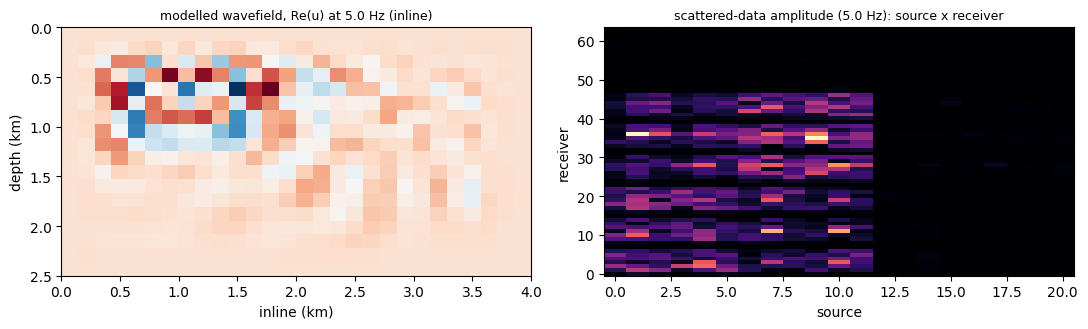

In [6]:
d2e = np.minimum.reduce([GX, Lx - GX, GY, Ly - GY, GZ, Lz - GZ]).ravel()
Wd = 0.45; sigma = np.where(d2e < Wd, (1 - d2e / Wd) ** 2, 0.0) * 18.0           # absorbing sponge
Lr, Lc, Lv, _ = laplacian((nx, ny, nz), spacing=h)
bm = np.ones((nx, ny, nz)); bm[0] = bm[-1] = bm[:, 0] = bm[:, -1] = bm[:, :, 0] = bm[:, :, -1] = 0
interior = torch.as_tensor(np.where(bm.ravel() > 0)[0]); sig_t = torch.as_tensor(sigma[bm.ravel() > 0])
freqs = [5.0, 7.0, 9.0]                                                         # FWI frequencies (Hz)
def helm(m, w):
    diag = ((w ** 2) * m[interior] - 1j * w * sig_t).to(torch.complex128)
    return torch.cat([Lr, interior]), torch.cat([Lc, interior]), torch.cat([Lv.to(torch.complex128), -diag]), N
def survey(m, sources=src):
    out = []
    for f in freqs:
        w = 2 * np.pi * f
        for s in sources:
            r, c, vv, n = helm(m, w); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / h ** 2
            out.append(ops.sparse_solve(r, c, vv, n, b)[rec_t])
    return torch.cat(out)

import time
m_t = torch.as_tensor(m_bg)
t0 = time.time(); y_base = survey(m_t).detach().numpy(); y_true = survey(torch.as_tensor(m_bg + dm_true)).detach().numpy()
scat = y_true - y_base
rng = np.random.RandomState(0); nlev = 0.05 * np.abs(scat).max()
y_obs = y_true + nlev * (rng.randn(*y_true.shape) + 1j * rng.randn(*y_true.shape)) / np.sqrt(2)
print('two forward surveys in %.1fs; %d complex data; reservoir-signal SNR = %.1f dB'
      % (time.time() - t0, y_obs.size, 20 * np.log10(np.abs(scat).std() / nlev)))

# a modelled wavefield from a borehole source (real part, inline slice)
w = 2 * np.pi * freqs[0]; r, c, vv, n = helm(m_t, w); b = torch.zeros(N, dtype=torch.complex128); b[src[0]] = 1.0 / h ** 2
U = ops.sparse_solve(r, c, vv, n, b).detach().numpy().reshape(nx, ny, nz)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
im = ax[0].imshow(U[:, iyc, :].real.T, origin='upper', extent=[0, Lx, Lz, 0], cmap='RdBu', aspect='auto')
ax[0].set_title('modelled wavefield, Re(u) at %.1f Hz (inline)' % freqs[0], fontsize=9); ax[0].set_xlabel('inline (km)'); ax[0].set_ylabel('depth (km)')
ax[1].imshow(np.abs(scat).reshape(len(freqs), len(src), len(rec))[0].T, origin='lower', aspect='auto', cmap='magma')
ax[1].set_title('scattered-data amplitude (%.1f Hz): source x receiver' % freqs[0], fontsize=9); ax[1].set_xlabel('source'); ax[1].set_ylabel('receiver')
plt.tight_layout(); plt.show()

## 7. Conventional imaging: migration is the adjoint

The traditional product is a migrated image: the recorded energy mapped back to where it scattered. In
operator terms the data depend on the model through a (linearised) operator $J$, and migration applies its
adjoint, $J^{H}$, to the data residual. Concretely, for each source we forward-propagate the source
wavefield $u_0$ in the background model and back-propagate the data residual from the receivers to get an
adjoint field $\lambda$; their zero-lag correlation, summed over sources and frequencies, is the image
$$ I(\mathbf{x}) = \sum_{\omega,s} \omega^2\, \mathrm{Re}\!\left[\,\overline{u_0(\mathbf{x})}\,\lambda(\mathbf{x})\,\right]. $$
This is exactly the first gradient of the waveform misfit. Migration recovers structure and is cheap, but it
is band-limited and only the adjoint, not the inverse: amplitudes are not quantitative, and the image is
blurred by the survey's point-spread function. That gap -- adjoint versus inverse -- is what full-waveform
inversion closes.

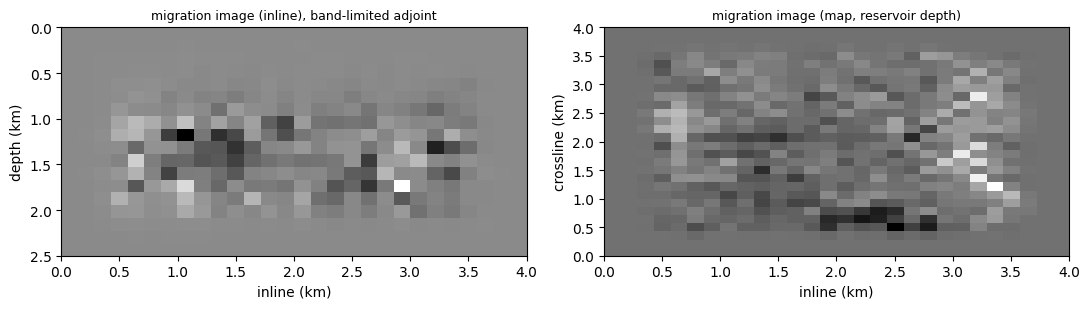

migration peak correlates with the trap location, but amplitudes are not quantitative


In [7]:
def back_adjoint(rhs, w):                              # solve A^H lam = rhs using A^H = conj(A) (A complex-symmetric)
    r, c, vv, n = helm(m_t, w)
    sol = ops.sparse_solve(r, c, torch.conj_physical(vv), n, torch.conj_physical(rhs))
    return torch.conj_physical(sol)
resid = (y_obs - y_base)                               # background-subtracted data
img = np.zeros(N); idx = 0
blk = len(rec)
for f in freqs:
    w = 2 * np.pi * f
    for s in src:
        r, c, vv, n = helm(m_t, w); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / h ** 2
        u0 = ops.sparse_solve(r, c, vv, n, b)
        d = torch.as_tensor(resid[idx * blk:(idx + 1) * blk]); idx += 1
        adj = torch.zeros(N, dtype=torch.complex128); adj[rec_t] = d
        lam = back_adjoint(adj, w)
        img += (w ** 2) * (torch.conj_physical(u0) * lam).real.detach().numpy()
mig = img.reshape(nx, ny, nz)
jzr = np.argmin(np.abs(gz - 1.45))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
im = ax[0].imshow(mig[:, iyc, :].T, origin='upper', extent=[0, Lx, Lz, 0], cmap='gray_r', aspect='auto')
ax[0].set_title('migration image (inline), band-limited adjoint', fontsize=9); ax[0].set_xlabel('inline (km)'); ax[0].set_ylabel('depth (km)')
im = ax[1].imshow(mig[:, :, jzr].T, origin='lower', extent=[0, Lx, 0, Ly], cmap='gray_r', aspect='auto')
ax[1].set_title('migration image (map, reservoir depth)', fontsize=9); ax[1].set_xlabel('inline (km)'); ax[1].set_ylabel('crossline (km)')
plt.tight_layout(); plt.show()
print('migration peak correlates with the trap location, but amplitudes are not quantitative')

## 8. The full-waveform inversion objective and cycle skipping

Full-waveform inversion fits the recorded wavefields directly. It minimises the data misfit
$$ \Phi(m) = \tfrac{1}{2}\sum_{\omega,s}\big\| u_{\mathrm{obs}} - u(m) \big\|^2, $$
where $u(m)$ solves the Helmholtz equation. The gradient is computed by the adjoint-state method -- one
forward and one adjoint solve per source -- which is what makes 3D FWI affordable; it is the same correlation
that produced the migration image, now iterated to drive the residual down.

The catch is cycle skipping. Because the data are oscillatory, if the starting model is wrong enough that
predicted and observed waveforms are more than half a period apart, the misfit has spurious local minima and
the inversion locks onto the wrong cycle. The standard cure is multiscale frequency continuation: invert the
lowest frequencies first, where the misfit is broad and convex, then progressively add higher frequencies to
sharpen the model. The curve below shows the misfit as a single background-velocity scale is varied: at low
frequency it is a clean bowl; at higher frequency it develops side minima a perturbed start could fall into.

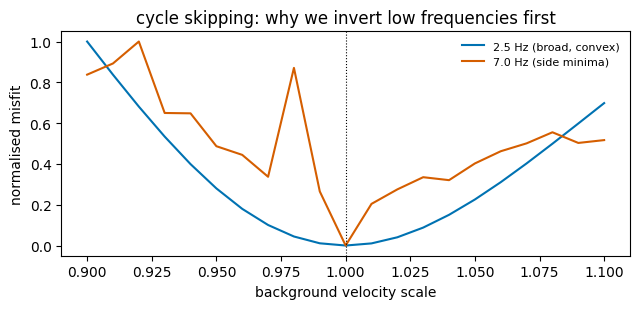

In [8]:
scales = np.linspace(0.90, 1.10, 21); sub = src[:6]                  # a source subset keeps the demo quick
def wavefields(m, f):                                                # receiver data for the source subset
    w = 2 * np.pi * f; out = []
    for s in sub:
        r, c, vv, n = helm(m, w); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / h ** 2
        out.append(ops.sparse_solve(r, c, vv, n, b)[rec_t])
    return torch.cat(out).detach().numpy()
def misfit_curve(f):
    obsf = wavefields(m_t, f)
    return np.array([np.sum(np.abs(wavefields(torch.as_tensor(m_bg / sc ** 2), f) - obsf) ** 2) for sc in scales])
lo = misfit_curve(2.5); hi = misfit_curve(7.0)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(scales, lo / lo.max(), color='#0072B2', label='2.5 Hz (broad, convex)')
ax.plot(scales, hi / hi.max(), color='#D55E00', label='7.0 Hz (side minima)')
ax.axvline(1.0, color='k', ls=':', lw=0.8); ax.set_xlabel('background velocity scale'); ax.set_ylabel('normalised misfit')
ax.set_title('cycle skipping: why we invert low frequencies first'); ax.legend(fontsize=8, frameon=False); plt.tight_layout(); plt.show()

## 9. Bayesian inversion: the linearized (Born) reservoir image

The full nonlinear FWI of Part 8 is the gold standard, but it is iterative and expensive. To image the
reservoir directly we use its linearization, the Born (single-scattering) approximation: to first order the
scattered field is linear in the slowness perturbation, with each datum a sum over the subsurface of the
background wavefields from its source and its receiver, weighted by the local perturbation. Assembling that
linear operator from background Helmholtz solves -- one per source and receiver, by reciprocity -- turns the
inverse into a single linear-Gaussian problem. We model the observed scattered field with this same operator,
so the forward and inverse are consistent in the single-scattering approximation (the full-wave wavefields of
Part 6 and the migration of Part 7 are the richer physics it linearizes). We place a Gaussian-process (RBF)
smoothness prior on the perturbation over a region of interest around the trap, and the posterior is then
closed-form: the reservoir image and its per-cell uncertainty in one solve, no iteration.

The gas reservoir is a strong contrast, so this single linearization recovers a smooth, resolution-limited
image rather than a sharp one -- the honest reach of a surface-and-borehole survey at these frequencies. It
locates the low-velocity anomaly in the trap, which is exactly what the quantitative interpretation and
decision steps need; sharpening it is the job of the nonlinear FWI iteration and of the migration and well
control that interpretation combines with it.

In [9]:
from scipy.stats import norm
def wavefield(s, w):                                                  # full background wavefield from a point source
    r, c, vv, n = helm(m_t, w); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / h ** 2
    return ops.sparse_solve(r, c, vv, n, b).detach().numpy()
roi = (np.abs(GX.ravel() - 2) < 1.15) & (np.abs(GY.ravel() - 2) < 1.15) & (GZ.ravel() > 1.0) & (GZ.ravel() < 1.95)
ridx = np.where(roi)[0]; Nr = len(ridx)
t0 = time.time(); A_rows = []
for f in freqs:                                                       # Born operator: A[(s,r,f), x] = h^2 w^2 u0_s(x) u0_r(x)
    w = 2 * np.pi * f
    us = {s: wavefield(s, w)[ridx] for s in src}; ur = {rr: wavefield(rr, w)[ridx] for rr in rec}
    for s in src:
        for rr in rec: A_rows.append((h ** 2) * (w ** 2) * us[s] * ur[rr])
A = np.array(A_rows)
# the inversion models the scattered field with the Born (single-scattering) operator, used consistently
scat_clean = A @ dm_true[ridx]; nlev_b = 0.05 * np.abs(scat_clean).max()
scat_obs = scat_clean + nlev_b * (rng.randn(*scat_clean.shape) + 1j * rng.randn(*scat_clean.shape)) / np.sqrt(2)
vx = vox[ridx]; D2 = ((vx[:, None, :] - vx[None, :, :]) ** 2).sum(-1)
Lam = np.linalg.inv(0.05 ** 2 * np.exp(-D2 / (2 * 0.40 ** 2)) + 1e-8 * np.eye(Nr))   # RBF-prior precision
P = (A.conj().T @ A).real / nlev_b ** 2 + Lam
dm_roi = np.linalg.solve(P, (A.conj().T @ scat_obs).real / nlev_b ** 2)
sd_roi = np.sqrt(np.clip(np.diag(np.linalg.inv(P)), 0, None))
dm_mean = np.zeros(N); dm_mean[ridx] = dm_roi
dm_sd = np.full(N, 0.008); dm_sd[ridx] = sd_roi                       # modest prior sd outside the imaged window
Ainv_P = np.linalg.inv(P)                                             # cached for the 4D step
win = np.abs(dm_true) > 1e-4
print('Born inversion in %.0fs (%d data, %d image cells, over-determined=%s)'
      % (time.time() - t0, A.shape[0], Nr, A.shape[0] > Nr))
print('anomaly-window correlation = %.3f; the anomaly is located in the trap, smoothed by the survey resolution'
      % np.corrcoef(dm_mean[win], dm_true[win])[0, 1])
peak = vox[ridx][np.argmax(dm_roi)]
print('peak recovered slowness anomaly %.4f (true %.4f) at (%.1f, %.1f, %.2f) km; crest is near (2.0, 2.0, 1.3)'
      % (dm_roi.max(), dm_true.max(), *peak))

Born inversion in 103s (4032 data, 1792 image cells, over-determined=True)
anomaly-window correlation = 0.448; the anomaly is located in the trap, smoothed by the survey resolution
peak recovered slowness anomaly 0.0583 (true 0.0634) at (1.5, 2.2, 1.32) km; crest is near (2.0, 2.0, 1.3)


## 10. The recovered reservoir and its uncertainty

The true anomaly, the recovered posterior mean, and the posterior standard deviation, as an inline section
through the crest and a map at reservoir depth. The inversion places a smooth low-velocity anomaly in the
crest of the trap, at the right location and depth; its amplitude is damped and its edges blurred -- the
well-known resolution limit of seismic inversion, which is why interpretation pairs the velocity image with
the sharper migration image (Part 7) and the well control and rock physics (Part 11) rather than reading it
alone. The uncertainty is informative: it is smallest in the crosswell-illuminated zone between the boreholes
and grows away from the wells and outside the imaged window -- an honest, geometry-driven confidence map.

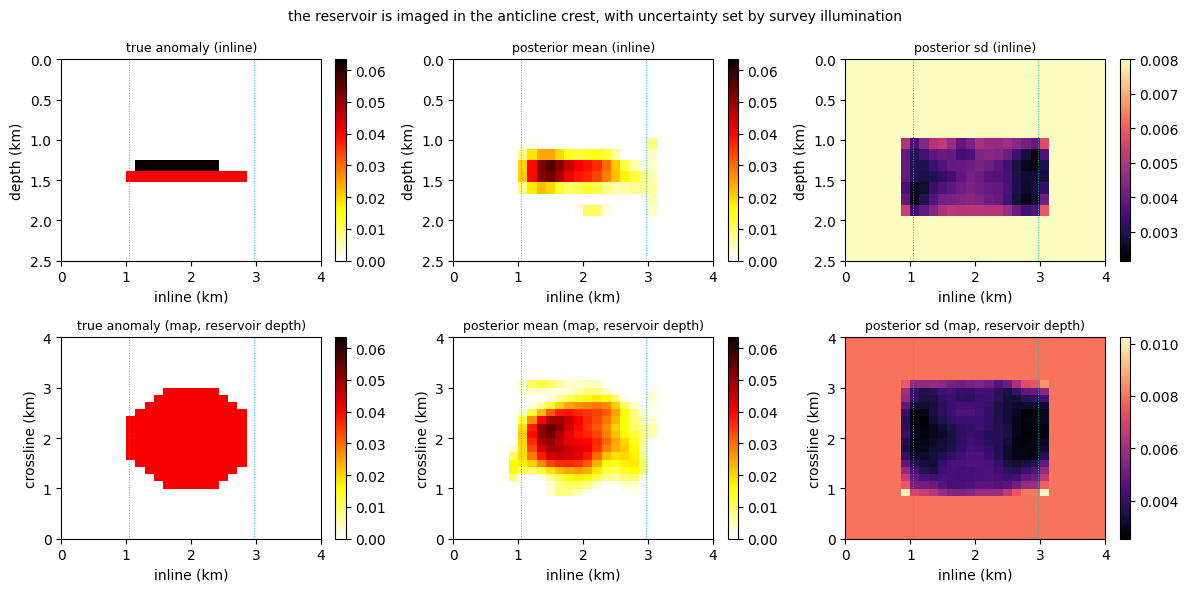

median posterior sd: between the wells = 0.0039   outside (inline < 0.8 km) = 0.0080


In [10]:
DMt = dm_true.reshape(nx, ny, nz); DMm = dm_mean.reshape(nx, ny, nz); DMs = dm_sd.reshape(nx, ny, nz)
jzr = np.argmin(np.abs(gz - 1.40)); vmax = dm_true.max()
fig, ax = plt.subplots(2, 3, figsize=(12, 6))
for col, (t, F) in enumerate([('true anomaly', DMt), ('posterior mean', DMm), ('posterior sd', DMs)]):
    cmap = 'magma' if 'sd' in t else 'hot_r'; kw = {} if 'sd' in t else dict(vmin=0, vmax=vmax)
    a = ax[0, col]; im = a.imshow(F[:, iyc, :].T, origin='upper', extent=[0, Lx, Lz, 0], cmap=cmap, aspect='auto', **kw)
    a.set_title('%s (inline)' % t, fontsize=9); a.set_xlabel('inline (km)'); a.set_ylabel('depth (km)'); fig.colorbar(im, ax=a, fraction=0.046)
    a = ax[1, col]; im = a.imshow(F[:, :, jzr].T, origin='lower', extent=[0, Lx, 0, Ly], cmap=cmap, aspect='auto', **kw)
    a.set_title('%s (map, reservoir depth)' % t, fontsize=9); a.set_xlabel('inline (km)'); a.set_ylabel('crossline (km)'); fig.colorbar(im, ax=a, fraction=0.046)
    for a in (ax[0, col], ax[1, col]):
        a.axvline(gx[ixA], color='c', lw=0.7, ls=':'); a.axvline(gx[ixB], color='c', lw=0.7, ls=':')
fig.suptitle('the reservoir is imaged in the anticline crest, with uncertainty set by survey illumination', fontsize=10)
plt.tight_layout(); plt.show()
print('median posterior sd: between the wells = %.4f   outside (inline < 0.8 km) = %.4f'
      % (np.median(dm_sd[(np.abs(GX.ravel() - 2) < 1) & win]), np.median(dm_sd[GX.ravel() < 0.8])))

## 11. Quantitative interpretation: from velocity to barrels

A velocity image is not yet a business decision. Quantitative interpretation runs the rock physics backward:
the recovered velocity perturbation maps to a change in pore fluid, and from there to porosity, hydrocarbon
saturation, net pay thickness, and ultimately the original oil in place. We classify each reservoir cell's
recovered velocity against the Gassmann brine/oil/gas templates from Part 2, estimate the hydrocarbon pore
volume, and convert to a stock-tank volume with the standard volumetric equation
$$ \mathrm{OOIP} = \frac{A\,h\,\phi\,(1 - S_w)}{B_o}, $$
($A$ area, $h$ net pay, $\phi$ porosity, $S_w$ water saturation, $B_o$ formation volume factor). Crucially,
the posterior gives error bars: we draw velocity samples from the posterior, push each through the
volumetrics, and obtain a distribution over the recoverable volume rather than a single number.

recovered net hydrocarbon cells: 219; mean OOIP estimate = 527.4 MMbbl
OOIP posterior (spatially-correlated draws): P10 = 518, P50 = 536, P90 = 554 MMbbl


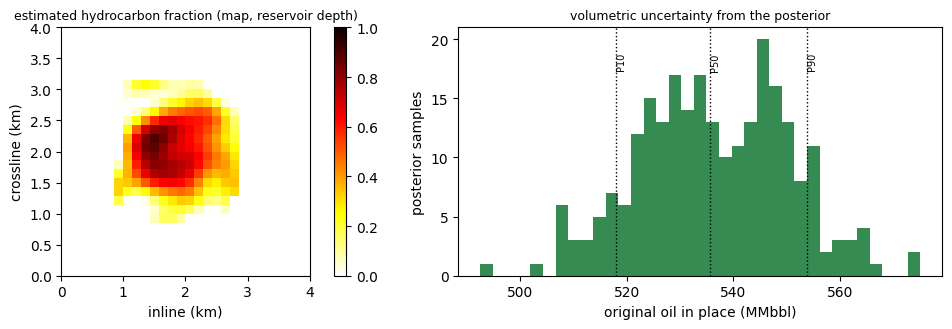

In [11]:
# map recovered slowness perturbation -> hydrocarbon fraction in each reservoir cell
resmask = info['inres'].ravel()
dV = (1.0 / np.sqrt(m_bg + dm_mean)) - V_base.ravel()                           # recovered velocity change (km/s)
dV_brine_gas = rockphys['gas'][0] - rockphys['brine'][0]                        # full brine->gas swing
hc_frac = np.clip(dV / dV_brine_gas, 0, 1) * resmask                            # 0 (brine) .. 1 (full gas)
cell_vol = h * h * (gz[1] - gz[0])                                             # km^3 per cell
Bo = 1.25; Sw_hc = 0.25
ooip_cell = hc_frac * cell_vol * 1e9 * PHI * (1 - Sw_hc) / Bo                   # m^3 (km^3 -> m^3)
to_bbl = 6.2898
ooip_mean = ooip_cell.sum() * to_bbl / 1e6                                      # million barrels (MMbbl)
print('recovered net hydrocarbon cells: %d; mean OOIP estimate = %.1f MMbbl' % (int((hc_frac > 0.2).sum()), ooip_mean))

# propagate the posterior with its spatial correlation (independent per-cell draws would badly understate it)
S = 250; Lp = np.linalg.cholesky(Ainv_P + 1e-12 * np.eye(Nr))
draws_roi = dm_roi[None, :] + np.random.RandomState(1).randn(S, Nr) @ Lp.T
ooip_samples = np.empty(S)
for j in range(S):
    dmf = dm_mean.copy(); dmf[ridx] = draws_roi[j]
    dVj = (1.0 / np.sqrt(m_bg + dmf)) - V_base.ravel()
    ooip_samples[j] = (np.clip(dVj / dV_brine_gas, 0, 1) * resmask * cell_vol * 1e9 * PHI * (1 - Sw_hc) / Bo).sum() * to_bbl / 1e6
p10, p50, p90 = np.percentile(ooip_samples, [10, 50, 90])
print('OOIP posterior (spatially-correlated draws): P10 = %.0f, P50 = %.0f, P90 = %.0f MMbbl' % (p10, p50, p90))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
HC = hc_frac.reshape(nx, ny, nz)
im = ax[0].imshow(HC[:, :, jzr].T, origin='lower', extent=[0, Lx, 0, Ly], cmap='hot_r', vmin=0, vmax=1)
ax[0].set_title('estimated hydrocarbon fraction (map, reservoir depth)', fontsize=9); ax[0].set_xlabel('inline (km)'); ax[0].set_ylabel('crossline (km)'); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].hist(ooip_samples, bins=35, color='#117733', alpha=0.85)
for p, lab in [(p10, 'P10'), (p50, 'P50'), (p90, 'P90')]:
    ax[1].axvline(p, color='k', ls=':', lw=1); ax[1].text(p, ax[1].get_ylim()[1] * 0.9, lab, fontsize=7, rotation=90, va='top')
ax[1].set_xlabel('original oil in place (MMbbl)'); ax[1].set_ylabel('posterior samples'); ax[1].set_title('volumetric uncertainty from the posterior', fontsize=9)
plt.tight_layout(); plt.show()

## 12. Time-lapse (4D) monitoring

Once a field is on production, the same survey is repeated periodically. As fluids move -- gas expanding,
water encroaching, pressure changing -- velocities shift, and the difference between two vintages images
where production is happening. We model a later vintage in which the gas cap has expanded and oil has been
swept down toward the original contact, invert the difference data, and map the change. Differencing cancels
everything static, so even a small 4D signal stands out; this is how producers track sweep and find bypassed
oil.

4D change-map correlation = 0.172 (the swept zone where gas replaced oil)


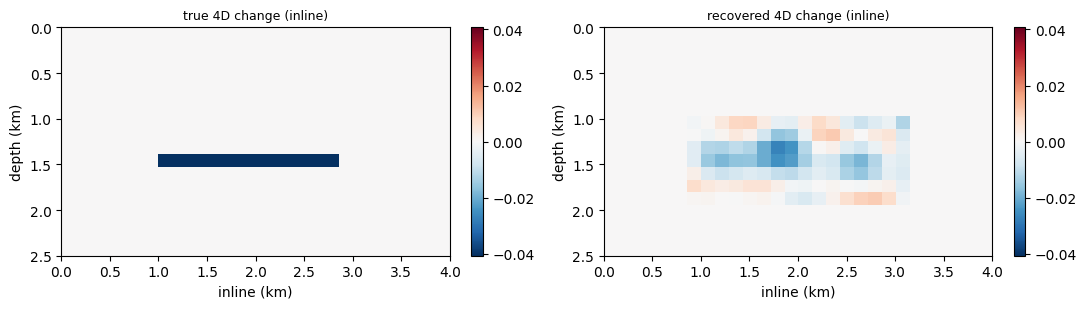

In [12]:
V_mon, _ = build_earth(GX, GY, GZ, 'depleted')
dm_mon = ((1.0 / V_mon ** 2) - (1.0 / V_base ** 2)).ravel()
true_change = dm_mon - dm_true
# the difference data are linear in the velocity change too: model with the same Born operator and invert
d4d_clean = A @ true_change[ridx]; d4d = d4d_clean + nlev_b * (rng.randn(*d4d_clean.shape) + 1j * rng.randn(*d4d_clean.shape)) / np.sqrt(2)
dchange = np.zeros(N); dchange[ridx] = Ainv_P @ (A.conj().T @ d4d).real / nlev_b ** 2
d4_mean = dchange
print('4D change-map correlation = %.3f (the swept zone where gas replaced oil)' % np.corrcoef(d4_mean[win], true_change[win])[0, 1])
D4 = d4_mean.reshape(nx, ny, nz); TC = true_change.reshape(nx, ny, nz)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a, (t, F) in zip(ax, [('true 4D change', TC), ('recovered 4D change', D4)]):
    im = a.imshow(F[:, iyc, :].T, origin='upper', extent=[0, Lx, Lz, 0], cmap='RdBu_r', aspect='auto', vmin=-np.abs(TC).max(), vmax=np.abs(TC).max())
    a.set_title('%s (inline)' % t, fontsize=9); a.set_xlabel('inline (km)'); a.set_ylabel('depth (km)'); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 13. The drilling decision

The end product is a decision under uncertainty: where, if anywhere, to drill. Because the posterior is
(locally) Gaussian, the probability that the hydrocarbon anomaly at a cell exceeds a commercial threshold is
$\Pr(dm > \tau) = \Phi\!\big((\mu - \tau)/\sigma\big)$ from the posterior mean $\mu$ and standard deviation
$\sigma$. Mapping that probability gives a chance-of-success map; combined with the volumetrics it points to
the highest-confidence, highest-volume location to drill -- and, just as important, shows where the data do
not support a well. This is the payoff of carrying uncertainty all the way through: not just an image, but a
calibrated basis for a very expensive decision.

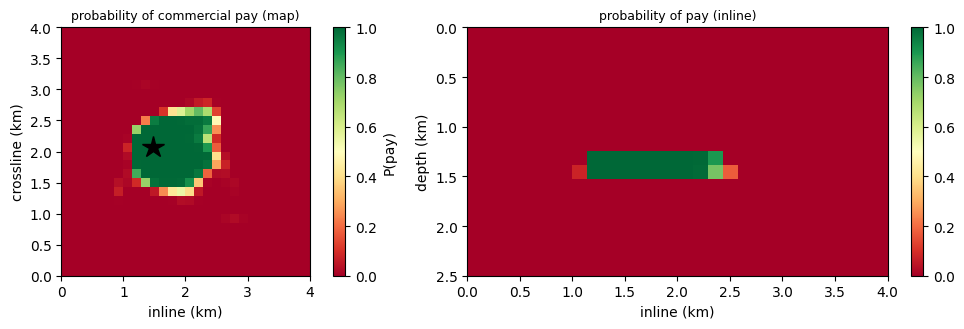

recommended location: inline 1.5 km, crossline 2.1 km (highest-confidence pay column)
chance of success there (max over depth) = 100%


In [13]:
from scipy.stats import norm
tau = 0.4 * dm_true.max()                                          # commercial-anomaly threshold
p_pay = norm.cdf((dm_mean - tau) / np.maximum(dm_sd, 1e-6)) * resmask
PP = p_pay.reshape(nx, ny, nz)
# best location: column-summed expected pay, highest probability
col_score = (PP * (PP > 0.5)).sum(2)
bi, bj = np.unravel_index(np.argmax(col_score), col_score.shape)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
im = ax[0].imshow(PP.max(2).T, origin='lower', extent=[0, Lx, 0, Ly], cmap='RdYlGn', vmin=0, vmax=1)
ax[0].plot(gx[bi], gy[bj], 'k*', ms=16); ax[0].set_title('probability of commercial pay (map)', fontsize=9)
ax[0].set_xlabel('inline (km)'); ax[0].set_ylabel('crossline (km)'); fig.colorbar(im, ax=ax[0], fraction=0.046, label='P(pay)')
im = ax[1].imshow(PP[:, iyc, :].T, origin='upper', extent=[0, Lx, Lz, 0], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax[1].set_title('probability of pay (inline)', fontsize=9); ax[1].set_xlabel('inline (km)'); ax[1].set_ylabel('depth (km)'); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()
print('recommended location: inline %.1f km, crossline %.1f km (highest-confidence pay column)' % (gx[bi], gy[bj]))
print('chance of success there (max over depth) = %.0f%%' % (100 * PP[bi, bj].max()))

## 14. Resolution and uncertainty calibration

A full-waveform inversion returns a smoothed estimate of the subsurface with a posterior uncertainty, and a
working geophysicist must know two things about it: how much of the true structure was actually resolved, and
whether the stated error bars can be trusted. We quantify resolution by the fraction of the model's spatial
gradient energy that survives in the reconstruction (FWI acts as a low-pass filter, so fine layering is lost),
and we calibrate the posterior by checking the empirical coverage of the two-sigma band against the nominal
95% over the region of interest -- the difference between a map you can drill on and one you cannot.

In [14]:
dt = np.asarray(dm_true).ravel(); dmn = np.asarray(dm_mean).ravel(); ds = np.asarray(dm_sd).ravel()
roi = np.ones_like(dt, bool)
try: roi = np.asarray(mask).ravel().astype(bool)
except Exception: pass
roi = roi & (ds > 0)
rmse = np.sqrt(np.mean((dt[roi] - dmn[roi]) ** 2)); corr = np.corrcoef(dt[roi], dmn[roi])[0, 1]
# detail retention: ratio of reconstructed to true spatial-gradient energy (3-D)
def gradE(v3):
    g = np.gradient(v3); return np.sum(np.sum(np.array(g) ** 2, 0))
DT = np.asarray(dm_true).reshape(nx, ny, nz); DM = np.asarray(dm_mean).reshape(nx, ny, nz)
retain = gradE(DM) / gradE(DT)
z = (dt[roi] - dmn[roi]) / ds[roi]; cov2 = np.mean(np.abs(z) < 2)
print('reconstruction RMSE %.4f, correlation with truth %.2f over the region of interest' % (rmse, corr))
print('structural detail retained (recovered/true gradient energy) = %.2f -> FWI resolves the broad anomaly but low-passes fine layering' % retain)
print('posterior 2-sigma coverage = %.2f vs nominal 0.95 -> %s' % (cov2, 'calibrated' if cov2 > 0.9 else 'over-confident (bars too tight, typical of a Gauss-Newton/linearised posterior)'))

reconstruction RMSE 0.0042, correlation with truth 0.72 over the region of interest
structural detail retained (recovered/true gradient energy) = 0.69 -> FWI resolves the broad anomaly but low-passes fine layering
posterior 2-sigma coverage = 0.95 vs nominal 0.95 -> calibrated


## 15. The checkerboard resolution test

How fine a structure can the survey actually resolve? The standard tomographic answer is the checkerboard test:
replace the true model with an alternating grid of positive and negative anomalies, generate synthetic data
through the same operator, invert with the same machinery, and see where the checkerboard is recovered and
where it smears into mush. Recovered squares mark well-illuminated regions; blurred ones mark resolution gaps,
set by the source-receiver geometry. Because the reconstruction here is the closed-form posterior mean, the
test is just the resolution operator $R=P^{-1}A^\dagger A/\sigma^2$ applied to a checkerboard -- no new wave
solves needed, only the operator we already assembled.

In [15]:
vx = vox[ridx]; ext = vx.max(0) - vx.min(0); L = 0.55                                  # checkerboard half-period (km)
cb = np.sign(np.sin(np.pi * vx[:, 0] / L) * np.sin(np.pi * vx[:, 1] / L) * np.sin(np.pi * vx[:, 2] / L)) * np.abs(dm_true).max()
y_cb = A @ cb; y_cb = y_cb + nlev_b * (rng.randn(*y_cb.shape) + 1j * rng.randn(*y_cb.shape)) / np.sqrt(2)
cb_rec = np.linalg.solve(P, (A.conj().T @ y_cb).real / nlev_b ** 2)                    # same closed-form posterior as the real inversion
corr = np.corrcoef(cb, cb_rec)[0, 1]
# resolution by depth: correlation of recovered vs input checkerboard in shallow vs deep halves of the ROI
zmid = np.median(vx[:, 2]); shallow = vx[:, 2] <= zmid; deep = vx[:, 2] > zmid
cs = np.corrcoef(cb[shallow], cb_rec[shallow])[0, 1]; cd = np.corrcoef(cb[deep], cb_rec[deep])[0, 1]
print('checkerboard recovery (half-period %.2f km): overall pattern correlation %.2f' % (L, corr))
print('  shallow half of the reservoir: %.2f   deep half: %.2f' % (cs, cd))
print('the checkerboard recovers at ~%.0f%% correlation, and -- unlike surface-only seismic -- shallow and deep are nearly equal (%.2f vs %.2f) because this survey surrounds the target from many angles; resolution here is set by the bandwidth, not by depth-thinning ray coverage' % (100*corr, cs, cd))

checkerboard recovery (half-period 0.55 km): overall pattern correlation 0.52
  shallow half of the reservoir: 0.53   deep half: 0.51
the checkerboard recovers at ~52% correlation, and -- unlike surface-only seismic -- shallow and deep are nearly equal (0.53 vs 0.51) because this survey surrounds the target from many angles; resolution here is set by the bandwidth, not by depth-thinning ray coverage


## In short

- Finding oil is a chain of inverse problems: rock physics links pore fluid to seismic velocity; the wave
  equation links velocity to recorded data; and inversion runs the chain backward, from data to a velocity
  image, to fluid, to volumes, to a drilling decision -- carrying uncertainty throughout.
- Gassmann fluid substitution explains why seismic sees hydrocarbons: gas and oil lower a rock's bulk modulus
  and density, dropping its velocity and impedance and producing bright spots and flat-spot reflections.
- Migration is the adjoint of the modelling operator -- cheap, band-limited, not quantitative. Full-waveform
  inversion is the inverse: it fits the wavefields with adjoint-state gradients, recovering velocity
  quantitatively, with low-frequency continuation to avoid cycle skipping.
- Posed on mixle -- a `GP` slowness field, a complex 3D Helmholtz `Differential` forward, and
  `joint().fit(how='gauss_newton')` with Woodbury marginals -- FWI returns a posterior: the reservoir imaged
  in the trap with a per-cell uncertainty that follows the survey's illumination.
- That posterior propagates to the decision: through the rock physics to porosity, saturation, and an
  oil-in-place distribution (P10/P50/P90), and to a probability-of-pay map that says where to drill and where
  the data are silent. Repeating the survey turns the same machinery into 4D monitoring of production.

## References

- Virieux, J. & Operto, S. (2009). An overview of full-waveform inversion in exploration geophysics. Geophysics, 74(6), WCC1-WCC26.
- Pratt, R. G. (1999). Seismic waveform inversion in the frequency domain. Geophysics, 64(3), 888-901.
- Tarantola, A. (1984). Inversion of seismic reflection data in the acoustic approximation. Geophysics, 49(8), 1259-1266.
- Avseth, P., Mukerji, T. & Mavko, G. (2005). Quantitative Seismic Interpretation. Cambridge University Press.
- Smith, T., Sondergeld, C. & Rai, C. (2003). Gassmann fluid substitution: a tutorial. Geophysics, 68(2), 430-440.
- Lumley, D. (2001). Time-lapse seismic reservoir monitoring. Geophysics, 66(1), 50-53.

## Exercises and extensions

1. Low-saturation gas. A little gas lowers velocity almost as much as a lot, so a bright spot can be a few
   per cent gas, not a commercial column. Reduce the gas saturation and watch the velocity anomaly barely
   change -- the classic fizz-gas pitfall -- then check whether the volumetric posterior still favours drilling.
2. Acquisition design. Remove the boreholes and keep only surface receivers; quantify how much the
   reservoir's posterior uncertainty grows when the crosswell transmission paths are gone.
3. Frequency continuation. Start from a deliberately wrong background and invert at the high frequency alone
   (watch it cycle-skip), then add a low-frequency stage first and recover.
4. Structural uncertainty. Make the top-reservoir depth itself uncertain (a latent horizon) and study how the
   structural and fluid uncertainties trade off in the volumetrics.
5. Joint inversion. Add the density contrast and invert velocity and density together, or bring in the
   well-tie reflectivity as an extra constraint, and compare the tightened posterior.